In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import bartlett
import numpy.linalg as nlg
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import RidgeCV
from sklearn.decomposition import PCA

/opt/conda/lib/python3.6/site-packages/sklearn/cross_validation.py:41: DeprecationWarning: This module was deprecated in version 0.18 in favor of the model_selection module into which all the refactored classes and functions are moved. Also note that the interface of the new CV iterators are different from that of this module. This module will be removed in 0.20.
  "This module will be removed in 0.20.", DeprecationWarning)


In [3]:
from warnings import filterwarnings
filterwarnings('ignore')

In [60]:
from numpy import log, sqrt
from pandas import concat
from pandas import DataFrame
from tqdm import tqdm


def calc_rc(symbol="000016.XSHG",
            date="2021-12-31",
            rolling_windows=30):
    data = get_index_weights(symbol, date=date)
    weight = data["weight"]
    weight /= 100
    universe = data.index.tolist()

    df = []
    for symbol in universe:
        data = get_price(security=symbol, end_date=date, count=rolling_windows + 1)
        tmp = log(data["close"] / data["close"].shift(1))
        tmp.name = symbol
        tmp = tmp.sort_index()
        tmp = tmp.iloc[1:].fillna(0.)
        df.append(tmp)
    df = concat(df, axis=1)

    # cov = df.cov()
    corr = df.corr().fillna(0.)
    sd = df.std(axis=0)

    su = 0
    sl = 0
    for i in range(1, len(universe)):
        for j in range(0, i):
            symbol_i = corr.index[i]
            symbol_j = corr.columns[j]
            w_i = weight[symbol_i]
            w_j = weight[symbol_j]
            rho = corr.loc[symbol_i, symbol_j]
            su += w_i * w_j * rho
            sl += w_i * w_j
    rc = su / sl
    return rc

In [61]:
def cal_avg_sigma(symbol, date, rolling_windows):
    data = get_index_weights(symbol, date=date)
    weight = data["weight"]
    weight /= 100
    universe = data.index.tolist()

    df = []
    for symbol in universe:
        data = get_price(security=symbol, end_date=date, count=rolling_windows + 1)
        tmp = log(data["close"] / data["close"].shift(1))
        tmp.name = symbol
        tmp = tmp.sort_index()
        tmp = tmp.iloc[1:].fillna(0.)
        df.append(tmp)
    df = concat(df, axis=1)
    n = rolling_windows # 样本数

    right = sum(df ** 2) / (n-1)
    left = df.sum() ** 2 / (n*(n-1))
    sigma = sqrt(right - left) * sqrt(255) # 单支成分股的年化波动率的估计统计量 sigma
    avg_sigma = mean(sigma * sqrt(weight)) # 成分股的加权平均年化波动率的估计值
    return avg_sigma

In [62]:
symbol = "000016.XSHG"
rolling_windows = 60
data = get_price(symbol, start_date="2016-01-01", end_date="2022-01-14")
df = []
for date in tqdm(data.index):
    date = date.strftime("%Y-%m-%d")
    rc = calc_rc(date=date, rolling_windows=rolling_windows)
    data = get_price(symbol, end_date=date, count=rolling_windows+1)
    price = data["close"].iloc[-1]
    hv = log(data["close"] / data["close"].shift(1)).iloc[1:].std() * sqrt(244) * 100
    avg_sigma = cal_avg_sigma(symbol=symbol, date=date, rolling_windows=rolling_windows)
    df.append([date, rc, hv, avg_sigma, price])
    
df = DataFrame(df)
df.columns = ["date", "RC{}".format(rolling_windows), "HV{}".format(rolling_windows),
              "AVG_SIGMA".format(rolling_windows), "上证50"]

100%|██████████| 1470/1470 [09:07<00:00,  2.51it/s]


In [4]:
df = pd.read_csv('SIGMA.csv')
df.set_index('date', inplace=True)

In [66]:
original_df = df

In [5]:
df = df[['RC60', 'HV60', 'AVG_SIGMA']].apply(lambda x: (x - x.mean())/x.std()) # 标准化 统一度量

"""
标准化不会影响其相关系数矩阵的数值 同时因为这三个变量均为构建的统计量，因此三个变量的数值之间的比较无统计意义,
标准化后方便对其进行下一步的回归分析，使回归结果更贴近其代表的实际情况。
"""

'\n标准化不会影响其相关系数矩阵的数值 同时因为这三个变量均为构建的统计量，因此三个变量的数值之间的比较无统计意义,\n标准化后方便对其进行下一步的回归分析，使回归结果更贴近其代表的实际情况。\n'

In [6]:
df.corr()

,RC60,HV60,AVG_SIGMA
RC60,1.000000,0.713443,0.354401
HV60,0.713443,1.000000,0.891864
AVG_SIGMA,0.354401,0.891864,1.000000


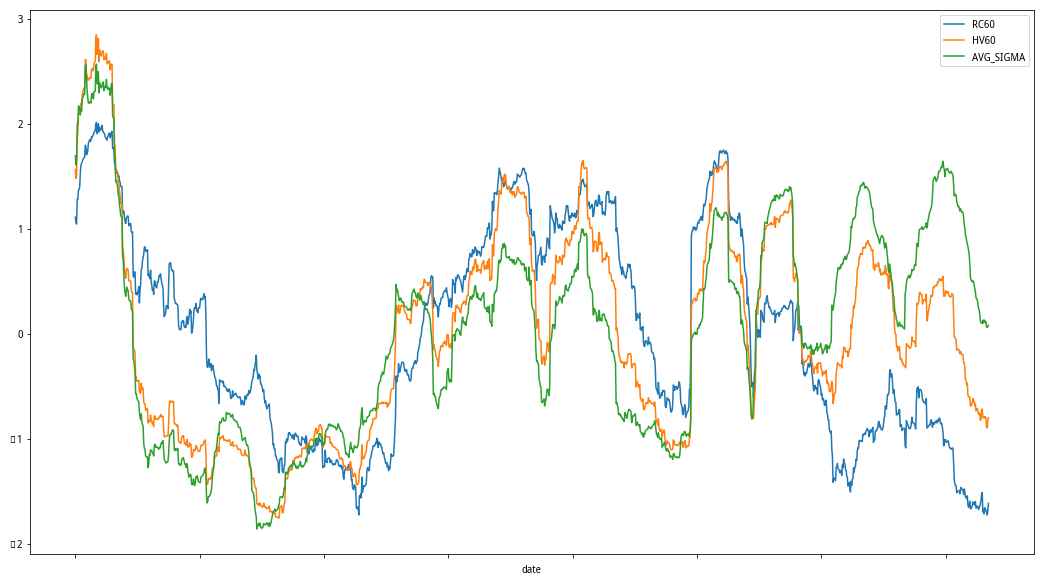

In [7]:
df.plot(figsize=(18,10))

In [8]:
"""
AVG_SIGMA与HV60的相关性达到了0.8918 AVG_SIGMA与RC60的相关性达到了0.7134
这说明hv的波动趋势与avg_sigma的波动趋势在很大程度上一致，也就是说有理由假设hv波动的原因很大程度上是取决于成分股的波动，
而不是成分股间波动的抵消。下面进一步的以HV60为因变量，AVG_SIGMA, RC60为自变量，对数据进行多元统计分析。
因为我们最终的目的是要找出影响rc变动的主要因素是avg-sigma（即成分股的平均波动率）还是rc（成分股之间的波动相关性的互相作用）
且两个自变量间相关系数达到了0.3544，下面我们建立模型的时候要着重处理这两者的共线性问题。
"""

'\nAVG_SIGMA与HV60的相关性达到了0.8918 AVG_SIGMA与RC60的相关性达到了0.7134\n这说明hv的波动趋势与avg_sigma的波动趋势在很大程度上一致，也就是说有理由假设hv波动的原因很大程度上是取决于成分股的波动，\n而不是成分股间波动的抵消。下面进一步的以HV60为因变量，AVG_SIGMA, RC60为自变量，对数据进行多元统计分析。\n因为我们最终的目的是要找出影响rc变动的主要因素是avg-sigma（即成分股的平均波动率）还是rc（成分股之间的波动相关性的互相作用）\n且两个自变量间相关系数达到了0.3544，下面我们建立模型的时候要着重处理这两者的共线性问题。\n'

In [9]:
# 数据预检验

In [10]:
x_dataset = df.iloc[:, [2,0]]
y = df.iloc[:, [1]]

In [11]:
def kmo(dataset_corr):
        corr_inv = np.linalg.inv(dataset_corr)
        nrow_inv_corr, ncol_inv_corr = dataset_corr.shape
        A = np.ones((nrow_inv_corr, ncol_inv_corr))
        for i in range(0, nrow_inv_corr, 1):
            for j in range(i, ncol_inv_corr, 1):
                A[i, j] = -(corr_inv[i, j]) / (math.sqrt(corr_inv[i, i] * corr_inv[j, j]))
                A[j, i] = A[i, j]
        dataset_corr = np.asarray(dataset_corr)
        kmo_num = np.sum(np.square(dataset_corr)) - np.sum(np.square(np.diagonal(A)))
        kmo_denom = kmo_num + np.sum(np.square(A)) - np.sum(np.square(np.diagonal(A)))
        kmo_value = kmo_num / kmo_denom
        return kmo_value


In [1]:
"""
下面我们用ols regression建立模型并进行方差分析去探究hv和rc、avg_sigma的关系。
"""

'\n下面我们用ols regression建立模型并进行方差分析去探究hv和rc、avg_sigma的关系。\n'

In [36]:
# ols regression

In [37]:
from statsmodels.formula.api import ols

In [38]:
formula = 'HV60 ~ RC60 + AVG_SIGMA'
model = ols(formula,df).fit()
anova_results = anova_lm(model)

In [39]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   HV60   R-squared:                       0.976
Model:                            OLS   Adj. R-squared:                  0.976
Method:                 Least Squares   F-statistic:                 2.983e+04
Date:                Mon, 17 Jan 2022   Prob (F-statistic):               0.00
Time:                        16:59:13   Log-Likelihood:                 656.03
No. Observations:                1470   AIC:                            -1306.
Df Residuals:                    1467   BIC:                            -1290.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -3.383e-17      0.004  -8.37e-15      1.000      -0.008       0.008
RC60           0.4544      0.004    105.065      0.000       0.446       0.463
AVG_SIGMA      0.7308      0.004    168.959      0.000       0.722       0.739
==============================================================================
Omnibus:                       20.536   Durbin-Watson:                   0.015
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               14.059
Skew:                          -0.111   Prob(JB):                     0.000885
Kurtosis:                       2.575   Cond. No.                         1.45
==============================================================================

Warnings:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [40]:
anova_results

,df,sum_sq,mean_sq,F,PR(>F)
RC60,1.0,747.722104,747.722104,31114.484616,0.0
AVG_SIGMA,1.0,686.023951,686.023951,28547.078612,0.0
Residual,1467.0,35.253945,0.024031,NaN,NaN


In [42]:
anova_results['sum_sq']/anova_results['sum_sq'].sum()

RC60         0.509001
AVG_SIGMA    0.467001
Residual     0.023999
Name: sum_sq, dtype: float64

In [49]:
# vif检验
from statsmodels.stats.outliers_influence import variance_inflation_factor
print(variance_inflation_factor(df.loc[:, ['RC60', 'AVG_SIGMA']].values, 1))

1.1436410241940476


In [2]:
"""
回归显示其标准化回归系数分别为0.73， 0.45。这两个自变量均对因变量有显著影响
其中RC60对因变量对方差解释占比达到了50.9%, avg_sigma对其方差解释占比达到了46.7%，总计97.6%。说明这两个自变量的变化直接决定了因变量的波动。

vif检验显示其不存在严重的共线性问题，当hv下降时，通常是avg_sigma与rc同时下降所作用的结果,
不存在hv与其中的一个因变量实际上不相关，而由于两个自变量本身的相关关系导致其相关系数较大的情况。

下面进一步分析是否存在avg_sigma 与 rc同时下降产生乘数效应导致hv更大幅度下降的情况
"""

'\n回归显示其标准化回归系数分别为0.73， 0.45。这两个自变量均对因变量有显著影响\n其中RC60对因变量对方差解释占比达到了50.9%, avg_sigma对其方差解释占比达到了46.7%，总计97.6%。说明这两个自变量的变化直接决定了因变量的波动。\n\nvif检验显示其不存在严重的共线性问题，当hv下降时，通常是avg_sigma与rc同时下降所作用的结果,\n不存在hv与其中的一个因变量实际上不相关，而由于两个自变量本身的相关关系导致其相关系数较大的情况。\n\n下面进一步分析是否存在avg_sigma 与 rc同时下降产生乘数效应导致hv更大幅度下降的情况\n'

In [18]:
# 构建乘数项检验交互作用

In [19]:
from statsmodels.stats.anova import anova_lm

In [21]:
# 双因素方差分析

In [22]:
# 构建交互项，需要将RC60转换为分类变量，以便进一步的方差分析。
df['RC60_cat'] = df['RC60'].map(lambda x: 0 if x<df['RC60'].quantile(0.2) 
               else 1 if df['RC60'].quantile(0.2)<=x<df['RC60'].quantile(0.4)
               else 2 if df['RC60'].quantile(0.4)<=x<df['RC60'].quantile(0.6) 
               else 3 if df['RC60'].quantile(0.6)<=x<df['RC60'].quantile(0.8)
               else 4)

In [23]:
df['RC60_cat*AVG_SIGMA'] = df['RC60_cat'] * df['AVG_SIGMA']
formula = 'HV60 ~ RC60_cat + AVG_SIGMA + RC60_cat*AVG_SIGMA'
model = ols(formula, df).fit()
anova_results = anova_lm(model)
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   HV60   R-squared:                       0.971
Model:                            OLS   Adj. R-squared:                  0.971
Method:                 Least Squares   F-statistic:                 1.655e+04
Date:                Mon, 17 Jan 2022   Prob (F-statistic):               0.00
Time:                        16:51:43   Log-Likelihood:                 525.08
No. Observations:                1470   AIC:                            -1042.
Df Residuals:                    1466   BIC:                            -1021.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -0.6005      0.008    -75.752      0.000      -0.616      -0.585
RC60_cat               0.2858      0.003     84.172      0.000       0.279       0.292
AVG_SIGMA              0.6297      0.008     81.455      0.000       0.615       0.645
RC60_cat:AVG_SIGMA     0.0666      0.003     21.044      0.000       0.060       0.073
==============================================================================
Omnibus:                        2.342   Durbin-Watson:                   0.166
Prob(Omnibus):                  0.310   Jarque-Bera (JB):                2.396
Skew:                          -0.082   Prob(JB):                        0.302
Kurtosis:                       2.890   Cond. No.                         5.97
==============================================================================

Warnings:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [34]:
anova_results

,df,sum_sq,mean_sq,F,PR(>F)
RC60_cat,1.0,646.621129,646.621129,22500.794139,0.000000e+00
AVG_SIGMA,1.0,767.523301,767.523301,26707.886602,0.000000e+00
RC60_cat:AVG_SIGMA,1.0,12.726098,12.726098,442.836318,4.053580e-86
Residual,1466.0,42.129472,0.028738,NaN,NaN


In [33]:
anova_results['sum_sq']/anova_results['sum_sq'].sum()

RC60_cat              0.440178
AVG_SIGMA             0.522480
RC60_cat:AVG_SIGMA    0.008663
Residual              0.028679
Name: sum_sq, dtype: float64

In [3]:
"""

回归分析结果可见三个自变量对hv60均有统计意义上显著的影响，p值均接近0
从方差分析结果中可见，avg_sigma和rc60解释了hv的大部分方差，累计方差贡献达到了96.25%，avg_sigma和rc60的交互作用虽然统计上显著，但是其方差解释程度
较低，只解释了0.8%的方差，其回归系数0.0666，相较于avg_sigma的0.6297和rc60的0.2858差距较大。因此交互作用虽然统计显著，但在实际意义上对hv
没有决定性影响。可以认为不存在戴维斯双击效应。


"""

'\n\n回归分析结果可见三个自变量对hv60均有统计意义上显著的影响，p值均接近0\n从方差分析结果中可见，avg_sigma和rc60解释了hv的大部分方差，累计方差贡献达到了96.25%，avg_sigma和rc60的交互作用虽然统计上显著，但是其方差解释程度\n较低，只解释了0.8%的方差，其回归系数0.0666，相较于avg_sigma的0.6297和rc60的0.2858差距较大。因此交互作用虽然统计显著，但在实际意义上对hv\n没有决定性影响。可以认为不存在戴维斯双击效应。\n\n\n'

In [5]:
"""

总结：
hv的波动和avg_sigma和rc均具有相关性，其中与avg_sigma的相关性更强。也就是说比如hv走低时，往往是avg_sigma和rc同时走低。
avg_sigma和rc的交互作用对hv没有主要影响，可以认为不存在戴维斯双击效应。


"""

'\n\n总结：\nhv的波动和avg_sigma和rc均具有相关性，其中与avg_sigma的相关性更强。也就是说比如hv走低时，往往是avg_sigma和rc同时走低。\navg_sigma和rc的交互作用对hv没有主要影响，可以认为不存在戴维斯双击效应。\n\n\n'

In [ ]:
# pca 不适用

In [155]:
"""
pca = PCA(n_components=None)  # n_components提取因子数量
pca.fit(x_dataset)
pca.explained_variance_  # 贡献方差，即特征根
pca.explained_variance_ratio_  # 方差贡献率
pca.components_  # 成分矩阵
k1_spss = pca.components_ / np.sqrt(pca.explained_variance_.reshape(-1, 1))  # 成分得分系数矩阵

In [157]:
 # pca.components_

array([[0.7071067811865479, 0.7071067811865471],
       [0.7071067811865471, -0.7071067811865479]])

In [165]:
# k1_spss

array([[0.6075911534638885, 0.6075911534638878],
       [0.8800420526466158, -0.8800420526466168]])